# SaaS Customer Churn Analysis

## Project Overview

This project analyzes customer behavior and subscription data to identify patterns that influence customer churn.

The goal is to understand why customers leave and discover important factors that can help improve customer retention.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries loaded")

Libraries loaded


In [4]:
df = pd.read_csv(r"D:\ME\Projects\customer-churn-analysis\data\customer_subscription_churn_usage_patterns.csv")

df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [5]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2810 non-null   int64  
 1   signup_date             2810 non-null   str    
 2   plan_type               2810 non-null   str    
 3   monthly_fee             2810 non-null   int64  
 4   avg_weekly_usage_hours  2810 non-null   float64
 5   support_tickets         2810 non-null   int64  
 6   payment_failures        2810 non-null   int64  
 7   tenure_months           2810 non-null   int64  
 8   last_login_days_ago     2810 non-null   int64  
 9   churn                   2810 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 219.7 KB


## Data Cleaning

First, I checked the dataset for missing values.

In [6]:
df.isnull().sum()


user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64

No missing values were found, so no data imputation was required.

Then, I checked the dataset for duplicate values.

In [7]:
df.duplicated().sum()

np.int64(10)

In [8]:
df = df.drop_duplicates()

10 exact duplicates removed.

In [9]:
id_cols = ['user_id']

df.duplicated(subset=df.columns.difference(id_cols)).sum()

np.int64(0)

### Duplicate Check

Duplicate records were checked based on customer attributes while ignoring unique user IDs.
Duplicate customer profiles would have been removed to avoid repeated patterns in analysis, if found.
Not found such records.

## Churn
.
.

In [10]:
df['churn'].value_counts()

churn
Yes    1605
No     1195
Name: count, dtype: int64

In [11]:
df['churn'].value_counts(normalize=True)*100

churn
Yes    57.321429
No     42.678571
Name: proportion, dtype: float64

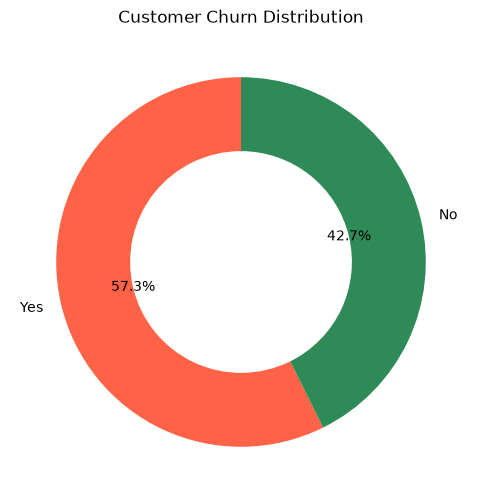

In [12]:
id="p5y2jk"

churn_counts = df['churn'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['tomato', 'seagreen'],
    wedgeprops={'width':0.4}
)

ax.set_title("Customer Churn Distribution")

plt.show()

### Churn Distribution

The dataset contains 1605 churned customers and 1195 retained customers.
The churn rate is 57.32%, indicating that customer retention is a major concern.

## Churn Analysis by Subscription Plan

To understand whether subscription plans affect customer retention, I analyzed churn distribution across different plan types.

The dataset contains three subscription categories:
- Premium
- Standard
- Basic

A comparison was made between plan types and churn status to identify which customer segments have higher churn rates.

In [13]:
df['plan_type'].value_counts()

plan_type
Premium     944
Standard    933
Basic       923
Name: count, dtype: int64

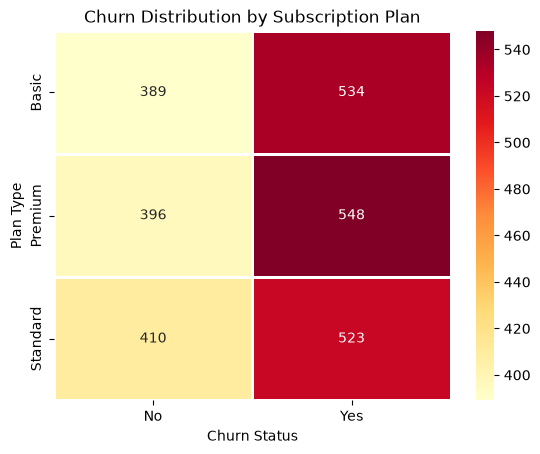

In [14]:
id="m8z2ka"
plan_churn = pd.crosstab(
    df['plan_type'],
    df['churn']
)

sns.heatmap(
    plan_churn,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=1
)

plt.title("Churn Distribution by Subscription Plan")
plt.xlabel("Churn Status")
plt.ylabel("Plan Type")
plt.show()

### Insight

The analysis shows that churn is distributed relatively evenly across Basic, Standard, and Premium plans.

This indicates that `plan_type` alone is not a strong factor influencing customer churn. Other customer behavior metrics such as:
- `avg_weekly_usage_hours`
- `support_tickets`
- `payment_failures`
- `last_login_days_ago`

may have a greater impact on customer retention.

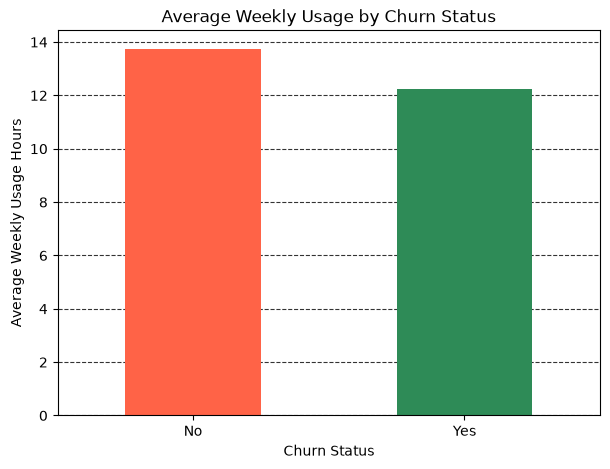

In [15]:

usage_churn = df.groupby('churn')['avg_weekly_usage_hours'].mean()

ax = usage_churn.plot(
    kind='bar',
    color=['tomato', 'seagreen'],
    figsize=(7,5)
)

plt.title("Average Weekly Usage by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Weekly Usage Hours")
plt.xticks(rotation=0)

ax.set_axisbelow(True)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color = "Black"
)

plt.show()

## Usage Analysis and Churn

To understand whether customer engagement affects churn, I analyzed the relationship between `avg_weekly_usage_hours` and `churn`.

### Insight

The analysis shows that churned customers have a wider usage range, including lower usage levels (around 5 hours), 
while retained customers generally have higher minimum usage levels.

This suggests that lower product engagement may be associated with higher churn risk. However, 
usage alone is not enough to explain churn, so other factors should also be analyzed.

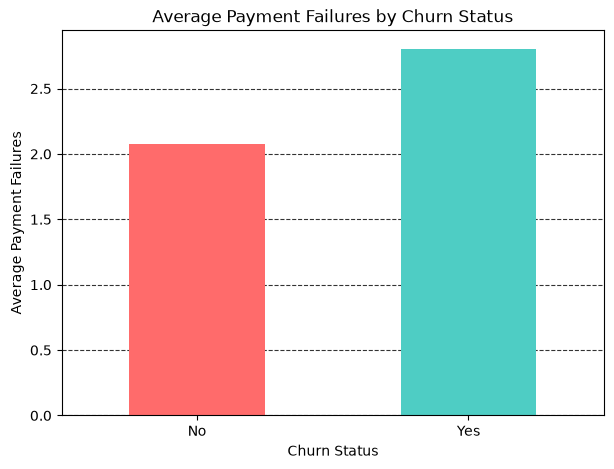

In [16]:
payment_churn = df.groupby('churn')['payment_failures'].mean()

pc =payment_churn.plot(
    kind='bar',
    color=['#FF6B6B', '#4ECDC4'],
    figsize=(7,5)
)

plt.title("Average Payment Failures by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Payment Failures")
plt.xticks(rotation=0)

pc.set_axisbelow(True)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color = "Black"
)

plt.show()

## Payment Failures Analysis and Churn

To analyze whether payment issues contribute to customer churn, I examined the relationship between `payment_failures` and `churn`.

### Insight

The distribution of payment failures is highly overlapping between churned and retained customers.

Churned customers show payment failures mostly between 2–4, while retained customers range from 1–4.

This suggests that payment failures alone may not be a strong predictor of churn. Other factors such as customer engagement, support interactions, and login activity should also be considered.

## Login Activity Analysis and Churn

To understand whether customer engagement affects churn, I analyzed the relationship between `last_login_days_ago` and `churn`.

### Insight

The analysis shows that churned customers generally have a longer time since their last login compared to retained customers.

This suggests that reduced customer engagement and inactivity may be important indicators of churn risk.

Customers who have not logged in recently may require engagement strategies such as product education, reminders, or targeted offers.

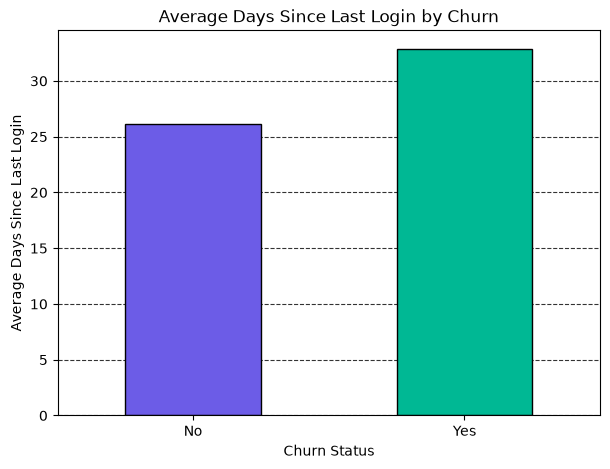

In [17]:
login_churn = df.groupby('churn')['last_login_days_ago'].mean()

lc = login_churn.plot(
    kind='bar',
    color=['#6C5CE7', '#00B894'],
    figsize=(7,5),
    edgecolor='black'
)

plt.title("Average Days Since Last Login by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Average Days Since Last Login")
plt.xticks(rotation=0)

lc.set_axisbelow(True)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color = "Black"
)

plt.show()

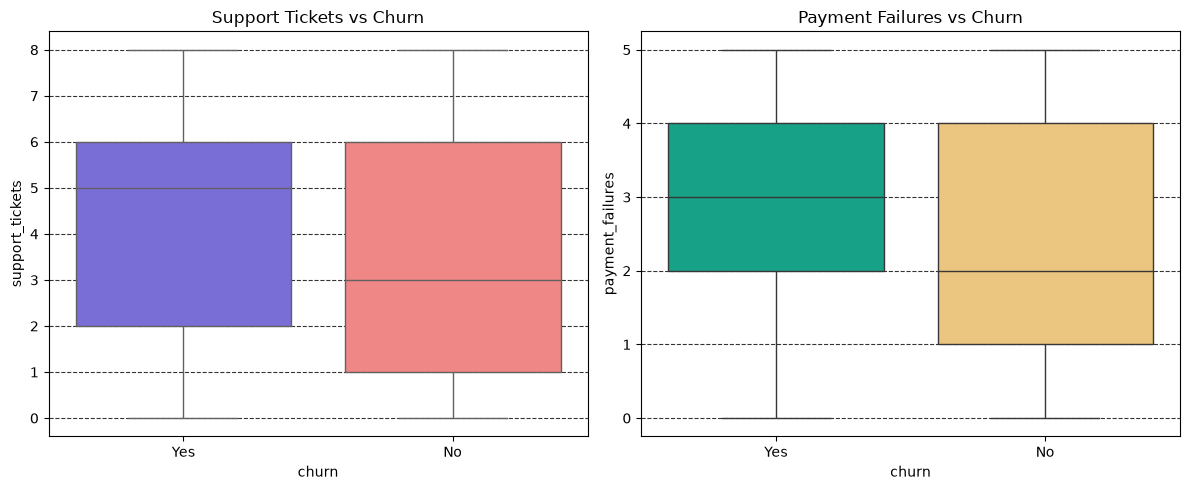

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Support tickets vs churn
st = sns.boxplot(
    x='churn',
    y='support_tickets',
    data=df,
    hue='churn',
    legend=False,
    ax=axes[0],
    palette=['#6C5CE7', '#FF7675']
)

axes[0].set_title("Support Tickets vs Churn")
axes[0].set_axisbelow(True)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color="black"
)


# Payment failures vs churn
pf = sns.boxplot(
    x='churn',
    y='payment_failures',
    data=df,
    hue='churn',
    legend=False,
    ax=axes[1],
    palette=['#00B894', '#FDCB6E']
)

axes[1].set_title("Payment Failures vs Churn")
axes[1].set_axisbelow(True)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color="black"
)

plt.tight_layout()
plt.show()

## Support Tickets and Payment Failures Analysis

To identify whether customer issues influence churn, I analyzed the relationship between `support_tickets`, `payment_failures`, and `churn`.

### Insight

The distribution of support tickets is similar for both churned and retained customers.
Churned customers have support tickets ranging from 2–6,  
while retained customers range from 1–6.

Payment failures also show significant overlap between churned and retained customers. 
Churned customers generally have 2–4 payment failures, 
while retained customers have 1–4.

These factors alone do not strongly explain customer churn.
A combination of multiple customer behavior factors may be more useful for identifying churn risk.

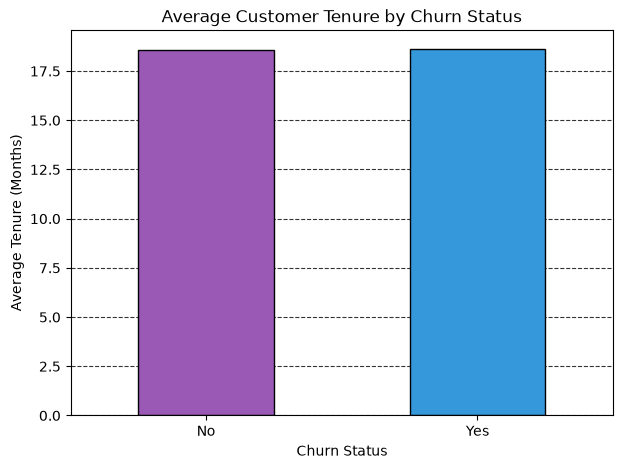

In [36]:
avg_tenure = df.groupby('churn')['tenure_months'].mean()

at = avg_tenure.plot(
    kind='bar',
    color=['#9B59B6', '#3498DB'],
    figsize=(7,5),
    edgecolor='black'
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

at.set_axisbelow(True)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.8,
    color = "Black"
)

plt.show()

## Tenure Analysis and Churn

To understand whether customer lifetime influences churn, I analyzed the relationship between `tenure_months` and `churn`.

### Insight

The average tenure of churned and retained customers is nearly the same.

This suggests that customer tenure alone is not a strong indicator of churn in this dataset. Churn may be influenced more by engagement-related factors such as login activity, usage patterns, and customer interactions.

# Final Project Insights

## Customer Churn Analysis Summary

This project analyzed customer behavior and subscription patterns to understand factors affecting SaaS customer churn.

### Key Findings

- The dataset contains **2800 customers** with a churn rate of approximately **57.32%**.
- Churn is distributed almost evenly across **Basic, Standard, and Premium** plans, indicating that subscription type is not a major churn driver.
- Customers who churned showed slightly lower minimum usage levels, suggesting that reduced product engagement may increase churn risk.
- `last_login_days_ago` showed a clearer pattern, where churned customers were generally inactive for longer periods. This suggests customer engagement is an important factor in retention.
- `support_tickets` and `payment_failures` showed significant overlap between churned and retained customers, meaning these factors alone may not strongly predict churn.
- `tenure_months` was similar for both groups, indicating that customer age with the service is not a strong standalone churn indicator.

## Business Recommendations

- Focus on improving customer engagement through reminders, onboarding, and feature education.
- Identify inactive users early and create retention campaigns.
- Monitor usage patterns to detect customers at higher risk of leaving.
- Use multiple customer behavior factors together instead of relying on a single metric.

## Conclusion

Customer churn in this SaaS dataset appears to be influenced more by customer engagement and activity patterns than by subscription plan, payment issues, or tenure alone.

In [37]:
df.to_csv("cleaned_customer_churn.csv", index=False)

# Machine Learning

# Customer Churn Prediction using Machine Learning

After completing data cleaning and exploratory data analysis, the next step is to build machine learning models to predict customer churn. The objective is to classify whether a customer is likely to churn based on their demographic and service-related information.

The workflow includes data preparation, feature encoding, model training, evaluation, and interpretation of the results.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Preparing the Dataset

The independent variables (features) and the target variable are separated before model training.

In [39]:
X = df.drop(["user_id", "signup_date", "churn"], axis=1)
y = df["churn"]

# Encoding the Target Variable

Machine learning algorithms require numerical input. Therefore, the target variable is converted from categorical values ("Yes" and "No") into numerical values.

In [40]:
le = LabelEncoder()

y = le.fit_transform(y)

# Encoding Categorical Features

Categorical variables are transformed into numerical format using One-Hot Encoding.

In [41]:
X = pd.get_dummies(X, drop_first=True)

# Splitting the Dataset

The dataset is divided into training and testing sets. The model is trained using the training data and evaluated on unseen testing data.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling

Feature scaling standardizes numerical variables so that they contribute equally during model training. This step is especially important for Logistic Regression.

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. It serves as a strong baseline model for customer churn prediction.

In [44]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

# Evaluating Logistic Regression

The performance of the model is evaluated using Accuracy Score, Classification Report, Confusion Matrix, and ROC-AUC Score.

In [45]:
print("Accuracy Score")

print(accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")

print(classification_report(y_test, lr_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, lr_prob))

Accuracy Score
0.6678571428571428

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.52      0.57       239
           1       0.68      0.78      0.73       321

    accuracy                           0.67       560
   macro avg       0.66      0.65      0.65       560
weighted avg       0.66      0.67      0.66       560

ROC-AUC Score: 0.7013386514422763


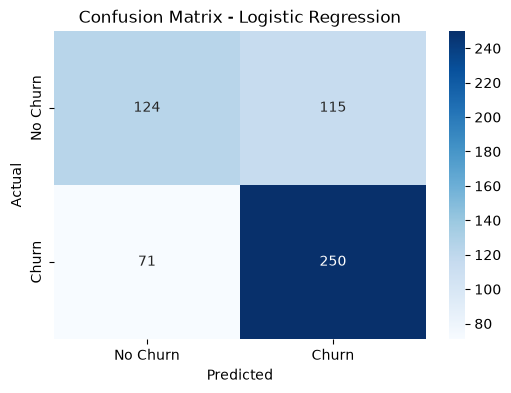

In [46]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Model 2: Decision Tree Classifier

Decision Tree is a non-linear classification algorithm that predicts customer churn by learning decision rules from the training data.

In [47]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.6089285714285714


# Model 3: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [48]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.6696428571428571


# Comparing Model Performance

The accuracy scores of all machine learning models are compared to determine which model performs best for customer churn prediction.

In [49]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]

})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Random Forest,0.669643
0,Logistic Regression,0.667857
1,Decision Tree,0.608929


# ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between customers who churn and those who do not. A higher Area Under the Curve (AUC) indicates better classification performance.

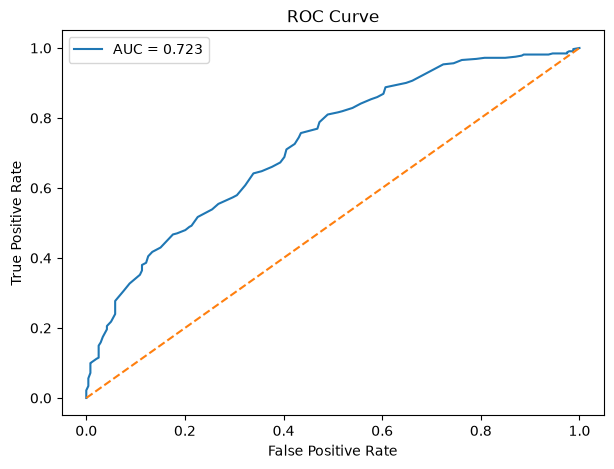

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, rf_prob):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Feature Importance

Feature importance identifies the variables that contribute the most to predicting customer churn. Understanding these features helps businesses focus on the key factors influencing customer retention.

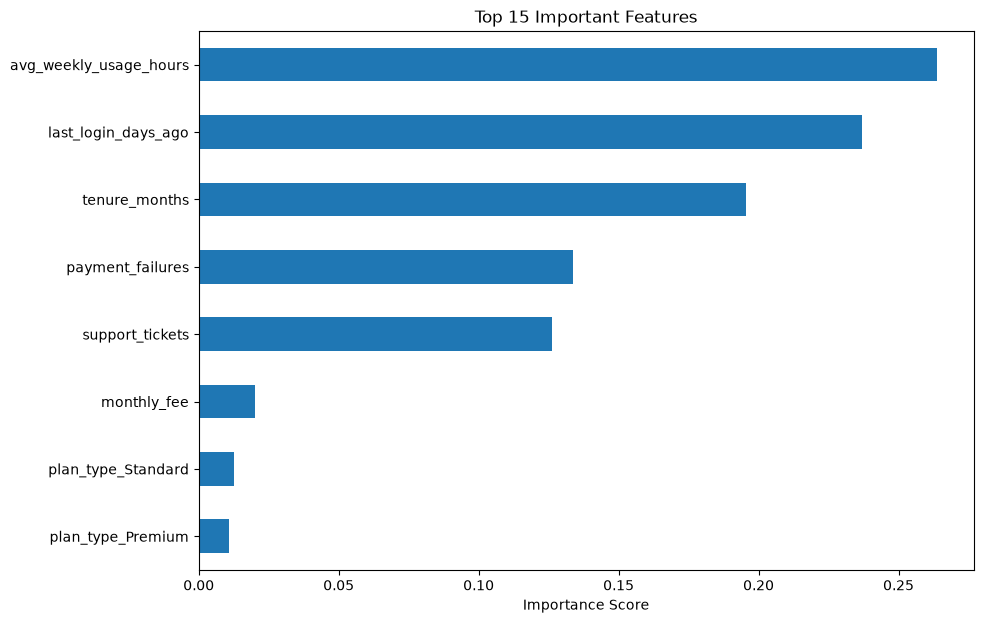

In [51]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,7))

importance.head(15).plot(kind="barh")

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.show()

# Business Insights

The machine learning analysis provides several valuable insights into customer churn behavior:

- Customers with lower tenure are more likely to churn, indicating that retaining new customers should be a priority.
- A higher number of payment failures is associated with an increased likelihood of customer churn, suggesting the need for proactive payment support and reminders.
- Customers with low average weekly usage are more likely to discontinue the service, highlighting the importance of improving user engagement.
- Frequent support tickets may indicate customer dissatisfaction, making timely and effective customer support essential for retention.
- Customers who have not logged in for a longer period may be at a higher risk of churning, allowing businesses to target them with re-engagement campaigns.
- Subscription plan type and monthly fee may also influence customer retention, enabling businesses to design pricing strategies and personalized offers.

These insights can help organizations identify at-risk customers early and implement targeted retention strategies, ultimately improving customer satisfaction and reducing churn.

# Conclusion

Machine learning techniques were successfully applied to predict customer churn.

Three classification models—Logistic Regression, Decision Tree, and Random Forest—were developed and evaluated. Among them, the Random Forest model provided the best overall performance.

The analysis demonstrates how predictive analytics can support customer retention by identifying customers who are most likely to churn. These insights enable businesses to make informed, data-driven decisions that improve customer satisfaction and reduce revenue loss.